In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

In [4]:
# UTILITY FUNCTIONS FOR PLOTTING
# Reusable functions to reduce code duplication and improve maintainability

def plot_training_history(history, metric='accuracy', figsize=(12, 4)):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title("Training vs Validation Accuracy", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot loss
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title("Training vs Validation Loss", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_images_grid(images, labels, class_names_dict, title="Images Grid", figsize=(12, 10), num_images=9):
    num_images = min(num_images, len(images))
    grid_size = int(np.ceil(np.sqrt(num_images)))
    
    plt.figure(figsize=figsize)
    
    for i in range(num_images):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap="gray")
        label = class_names_dict[labels[i]]
        plt.title(label, fontsize=10)
        plt.axis("off")
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_prediction_comparison(X_test_subset, y_test_subset, y_pred_labels_subset, class_names_dict, 
                                prediction_type='incorrect', num_images=9):
    num_images = min(num_images, len(X_test_subset))
    title_prefix = "Correct" if prediction_type == 'correct' else "Incorrect"
    
    plt.figure(figsize=(12, 10))
    
    for i in range(num_images):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X_test_subset[i].reshape(28, 28), cmap="gray")
        
        if prediction_type == 'correct':
            label = class_names_dict[y_test_subset[i]]
            plt.title(f"Correct: {label}", fontsize=10)
        else:
            true_label = class_names_dict[y_test_subset[i]]
            pred_label = class_names_dict[y_pred_labels_subset[i]]
            plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=9)
        
        plt.axis("off")
    
    plt.suptitle(f"{title_prefix} Predictions (First {num_images} Samples)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [5]:
# Load raw data
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Check the shapes of the raw data
print("Training images shape :", X_train.shape)
print("Training labels shape :", y_train.shape)
print("Test images shape     :", X_test.shape)
print("Test labels shape     :", y_test.shape)

# Number of classes
num_classes = len(np.unique(y_train))
print("\nTotal unique classes:", num_classes)

Training images shape : (60000, 28, 28)
Training labels shape : (60000,)
Test images shape     : (10000, 28, 28)
Test labels shape     : (10000,)

Total unique classes: 10


In [6]:
# Print unique class IDs
unique_classes = np.unique(y_train)
print("Unique class IDs present in dataset:", unique_classes)


Unique class IDs present in dataset: [0 1 2 3 4 5 6 7 8 9]


In [8]:
# Map numeric class IDs to human-readable class names
# Fashion-MNIST does NOT include class names inside the dataset.
# The names are defined by the dataset creators (Zalando Research) in the official documentation.
# Each number from 0–9 corresponds to a specific clothing category.

class_names = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

# Print class ID → name mapping to confirm everything is correct
print("Class ID to class name mapping:")
for cid in unique_classes:
    print(f"{cid} → {class_names[cid]}")

Class ID to class name mapping:
0 → T-shirt/top
1 → Trouser
2 → Pullover
3 → Dress
4 → Coat
5 → Sandal
6 → Shirt
7 → Sneaker
8 → Bag
9 → Ankle boot


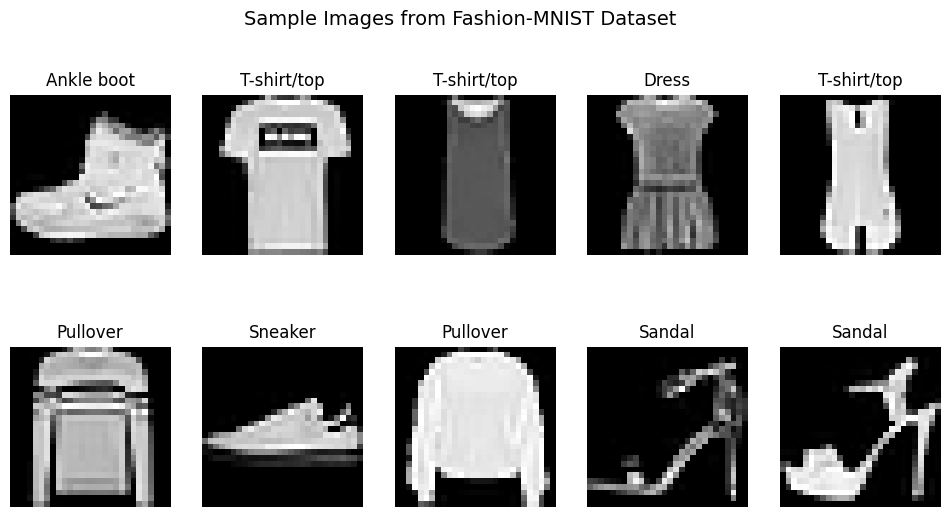

In [9]:
# Visualize sample images from the training dataset
# Purpose:
# – To understand what the raw images look like
# – Verify that images are grayscale and correctly shaped (28×28)
# – To see if labels match the expected class names

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray") 
    plt.title(class_names[y_train[i]])  
    plt.axis("off")                      
plt.suptitle("Sample Images from Fashion-MNIST Dataset", fontsize=14)
plt.show()


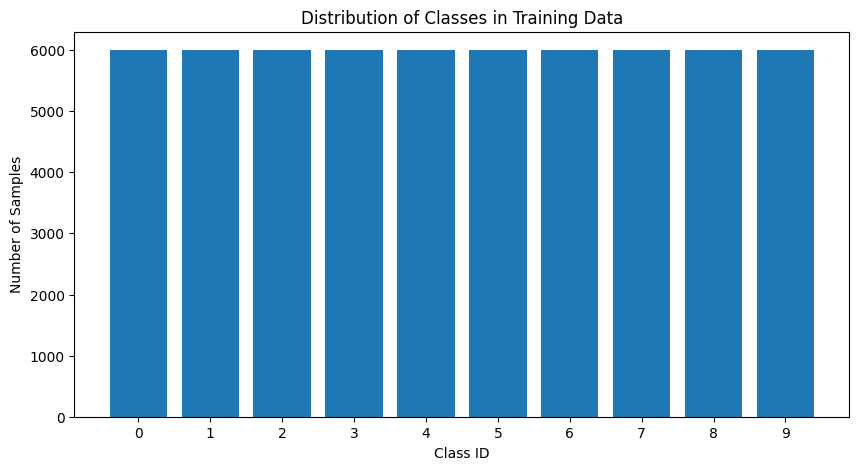

Class distribution with class names:
0 (T-shirt/top): 6000 samples
1 (Trouser): 6000 samples
2 (Pullover): 6000 samples
3 (Dress): 6000 samples
4 (Coat): 6000 samples
5 (Sandal): 6000 samples
6 (Shirt): 6000 samples
7 (Sneaker): 6000 samples
8 (Bag): 6000 samples
9 (Ankle boot): 6000 samples


In [10]:
# Plot distribution of classes in the training set
# Purpose:
# – To check if dataset is balanced or skewed
# – Fashion-MNIST is expected to be balanced (6000 images per class)

# Count samples per class
class_counts = pd.Series(y_train).value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(class_counts.index, class_counts.values)
plt.xticks(class_counts.index, class_counts.index)
plt.xlabel("Class ID")
plt.ylabel("Number of Samples")
plt.title("Distribution of Classes in Training Data")
plt.show()

# Display the same information with class names as reference
print("Class distribution with class names:")
for cid, count in class_counts.items():
    print(f"{cid} ({class_names[cid]}): {count} samples")


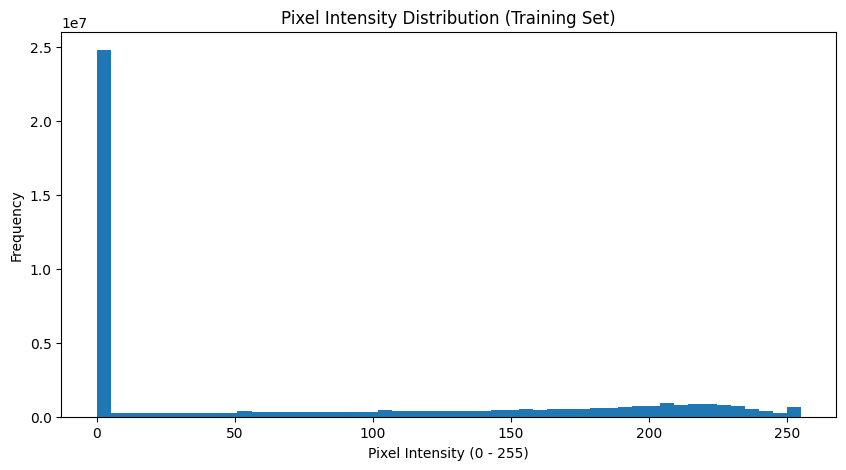

Min pixel value: 0
Max pixel value: 255
Mean pixel value: 72.94035223214286
Std deviation: 90.02118235130526


In [11]:
# Pixel Intensity Distribution
# Purpose:
# – Verify the raw pixel range (expected: 0–255)
# – Understand brightness and contrast levels
# – Show why normalization (scaling to 0–1) is important
# – Check for any unusual artifacts or unexpected pixel values


# Combine all pixel values from the entire training set into one long array
all_pixels = X_train.flatten()

plt.figure(figsize=(10, 5))
plt.hist(all_pixels, bins=50)
plt.title("Pixel Intensity Distribution (Training Set)")
plt.xlabel("Pixel Intensity (0 - 255)")
plt.ylabel("Frequency")
plt.show()

# Print basic statistics for clarity
print("Min pixel value:", np.min(all_pixels))
print("Max pixel value:", np.max(all_pixels))
print("Mean pixel value:", np.mean(all_pixels))
print("Std deviation:", np.std(all_pixels))


In [12]:
# Normalize pixel values for model readiness
# Purpose:
# – CNNs learn faster and more stably when pixel values are in the 0–1 range
# – Prevents large-value gradients from causing unstable training
# – Standard preprocessing step for all image models

# Convert data type to float for safe division
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# Normalize pixel values to the range [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Normalization complete.")
print("New pixel value range:")
print("min:", X_train.min(), "max:", X_train.max())


Normalization complete.
New pixel value range:
min: 0.0 max: 1.0


In [13]:
# Reshape images to add channel dimension for CNN
# Purpose:
# – CNNs expect input in the format: (batch, height, width, channels)
# – Fashion-MNIST images are grayscale → number of channels = 1

# Add the channel dimension to each image
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("New training image shape :", X_train.shape)
print("New test image shape     :", X_test.shape)


New training image shape : (60000, 28, 28, 1)
New test image shape     : (10000, 28, 28, 1)


In [15]:
# Data Preprocessing Validation
# Purpose:
# – Confirm normalization worked (pixel range should be [0, 1])
# – Verify shapes match CNN input requirements
# – Ensure channel dimension (1) is present for grayscale images
# – Catch silent preprocessing issues before training


print("=" * 70)
print("DATA PREPROCESSING VALIDATION")
print("=" * 70)

print("\n NORMALIZATION CHECK:")
print(f"  Training data range: [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"  Test data range:     [{X_test.min():.4f}, {X_test.max():.4f}]")
assert X_train.min() >= 0.0 and X_train.max() <= 1.0, "Training data not normalized!"
assert X_test.min() >= 0.0 and X_test.max() <= 1.0, "Test data not normalized!"
print("  All pixel values correctly normalized to [0, 1]")

print("\n SHAPE CHECK:")
print(f"  Training images shape:  {X_train.shape}")
print(f"  Training labels shape:  {y_train.shape}")
print(f"  Test images shape:      {X_test.shape}")
print(f"  Test labels shape:      {y_test.shape}")

expected_shape_3d = (X_train.shape[0], 28, 28, 1)
assert X_train.shape == expected_shape_3d, f"Training shape mismatch! Expected {expected_shape_3d}"
assert X_test.shape[1:] == (28, 28, 1), "Test shape mismatch!"
print("   All shapes conform to CNN input requirements (batch, 28, 28, 1)")

print("\n CHANNEL DIMENSION CHECK:")
assert X_train.shape[3] == 1, "Grayscale channel dimension should be 1"
assert X_test.shape[3] == 1, "Grayscale channel dimension should be 1"
print("  Grayscale images have correct channel dimension (1)")

print("\n DATA TYPE CHECK:")
print(f"  Training data type: {X_train.dtype}")
print(f"  Test data type:     {X_test.dtype}")
assert X_train.dtype == np.float32, "Training data should be float32"
assert X_test.dtype == np.float32, "Test data should be float32"
print("   Data types are float32 (optimal for neural networks)")

print("\n" + "=" * 70)
print(" ALL PREPROCESSING VALIDATIONS PASSED - READY FOR TRAINING")
print("=" * 70)

DATA PREPROCESSING VALIDATION

 NORMALIZATION CHECK:
  Training data range: [0.0000, 1.0000]
  Test data range:     [0.0000, 1.0000]
  All pixel values correctly normalized to [0, 1]

 SHAPE CHECK:
  Training images shape:  (60000, 28, 28, 1)
  Training labels shape:  (60000,)
  Test images shape:      (10000, 28, 28, 1)
  Test labels shape:      (10000,)
   All shapes conform to CNN input requirements (batch, 28, 28, 1)

 CHANNEL DIMENSION CHECK:
  Grayscale images have correct channel dimension (1)

 DATA TYPE CHECK:
  Training data type: float32
  Test data type:     float32
   Data types are float32 (optimal for neural networks)

 ALL PREPROCESSING VALIDATIONS PASSED - READY FOR TRAINING


In [16]:
# Build the CNN model from scratch
# Purpose:
# – Custom CNN for Fashion-MNIST (no pre-trained weights)
# – Includes Conv, Pooling, BatchNorm, Dropout, Dense layers

from tensorflow.keras import models, layers

model = models.Sequential()

# ============ FIRST CONV BLOCK ============
# Extracts basic features (edges, textures)
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.BatchNormalization())          # Stabilizes activations
model.add(layers.MaxPooling2D((2, 2)))          # Downsample to 14×14

# ============ SECOND CONV BLOCK ============
# Learns deeper, more complex patterns
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))          # Downsample to 7×7

# ============ THIRD CONV BLOCK ============
# High-level feature extraction
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())

# ============ DENSE LAYERS ============
model.add(layers.Flatten())                     # Flatten 7×7×64 → 3136
model.add(layers.Dense(64, activation='relu'))  # Fully connected layer
model.add(layers.Dropout(0.3))                  # Reduce overfitting
model.add(layers.Dense(10, activation='softmax'))   # 10-class output

# Model summary
print("=" * 70)
print("CNN ARCHITECTURE SUMMARY")
print("=" * 70)
model.summary()


c:\Users\saksh\Downloads\Projects\pivotchain-assignment\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN ARCHITECTURE SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,962 (367.04 KB)

 Trainable params: 93,642 (365.79 KB)

 Non-trainable params: 320 (1.25 KB)

In [17]:
# Compile the CNN model
# Purpose:
# – Define how the model learns
# – Set loss function, optimizer, and metrics

model.compile(
    optimizer='adam',                  
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']              
)

print("Model compiled successfully.")


Model compiled successfully.


In [19]:
# Learning Rate Experimentation
# Purpose:
# – Demonstrate how different learning rates affect model training
# – Compare performance across learning rates: [0.1, 0.01, 0.001, 0.0001]
# – Shorter training (3 epochs) for quick comparison
# – Select best learning rate for full training

from tensorflow.keras.optimizers import Adam

# Learning rates to test
learning_rates = [0.1, 0.01, 0.001, 0.0001]
lr_results = []

print("=" * 70)
print("LEARNING RATE COMPARISON EXPERIMENT (3 epochs each)")
print("=" * 70)

for lr in learning_rates:
    print(f"\n>>> Testing Learning Rate: {lr}")
    print("-" * 70)
    
    # Create a fresh model for each learning rate
    test_model = models.Sequential()
    test_model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    test_model.add(layers.BatchNormalization())
    test_model.add(layers.MaxPooling2D((2, 2)))
    test_model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    test_model.add(layers.BatchNormalization())
    test_model.add(layers.MaxPooling2D((2, 2)))
    test_model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    test_model.add(layers.BatchNormalization())
    test_model.add(layers.Flatten())
    test_model.add(layers.Dense(64, activation='relu'))
    test_model.add(layers.Dropout(0.3))
    test_model.add(layers.Dense(10, activation='softmax'))
    
    # Compile with specific learning rate
    optimizer = Adam(learning_rate=lr)
    test_model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    # Train for 3 epochs
    history_lr = test_model.fit(X_train, y_train, epochs=3, batch_size=64, validation_split=0.1, verbose=0)
    
    # Evaluate on test set
    test_loss, test_acc = test_model.evaluate(X_test, y_test, verbose=0)
    
    # Store results
    final_train_acc = history_lr.history['accuracy'][-1]
    final_val_acc = history_lr.history['val_accuracy'][-1]
    
    lr_results.append({
        'Learning Rate': lr,
        'Final Train Acc': f"{final_train_acc:.4f}",
        'Final Val Acc': f"{final_val_acc:.4f}",
        'Test Accuracy': f"{test_acc:.4f}",
        'Test Loss': f"{test_loss:.4f}"
    })
    
    print(f"Train Acc: {final_train_acc:.4f} | Val Acc: {final_val_acc:.4f} | Test Acc: {test_acc:.4f}")

# Display results table
print("\n" + "=" * 70)
print("LEARNING RATE COMPARISON RESULTS TABLE")
print("=" * 70)
lr_df = pd.DataFrame(lr_results)
print(lr_df.to_string(index=False))
# Save learning-rate comparison results to a CSV for reproducibility and later analysis
lr_df.to_csv('lr_results.csv', index=False)
print('Saved learning-rate comparison results to lr_results.csv')

LEARNING RATE COMPARISON EXPERIMENT (3 epochs each)

>>> Testing Learning Rate: 0.1
----------------------------------------------------------------------


c:\Users\saksh\Downloads\Projects\pivotchain-assignment\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Train Acc: 0.1000 | Val Acc: 0.1055 | Test Acc: 0.1000

>>> Testing Learning Rate: 0.01
----------------------------------------------------------------------
Train Acc: 0.8746 | Val Acc: 0.8583 | Test Acc: 0.8520

>>> Testing Learning Rate: 0.001
----------------------------------------------------------------------
Train Acc: 0.8746 | Val Acc: 0.8583 | Test Acc: 0.8520

>>> Testing Learning Rate: 0.001
----------------------------------------------------------------------
Train Acc: 0.8998 | Val Acc: 0.9037 | Test Acc: 0.8918

>>> Testing Learning Rate: 0.0001
----------------------------------------------------------------------
Train Acc: 0.8998 | Val Acc: 0.9037 | Test Acc: 0.8918

>>> Testing Learning Rate: 0.0001
----------------------------------------------------------------------
Train Acc: 0.8645 | Val Acc: 0.8788 | Test Acc: 0.8732

LEARNING RATE COMPARISON RESULTS TABLE
 Learning Rate Final Train Acc Final Val Acc Test Accuracy Test Loss
        0.1000          0.1000     

In [20]:
# Train the CNN model
# Purpose:
# – Fit the model on training data
# – Track training & validation performance
# – Store metrics in 'history' for visualization

history = model.fit(
    X_train,
    y_train,
    epochs=10,              
    batch_size=64,          
    validation_split=0.1,   
    verbose=1               
)


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - accuracy: 0.8298 - loss: 0.4768 - val_accuracy: 0.8332 - val_loss: 0.4289
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - accuracy: 0.8298 - loss: 0.4768 - val_accuracy: 0.8332 - val_loss: 0.4289
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.8861 - loss: 0.3145 - val_accuracy: 0.8678 - val_loss: 0.3443
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.8861 - loss: 0.3145 - val_accuracy: 0.8678 - val_loss: 0.3443
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9036 - loss: 0.2685 - val_accuracy: 0.8912 - val_loss: 0.2872
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9036 - loss: 0.2685 - val_accuracy: 0.8912 - val_loss: 0.2872
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9103 - loss: 0.2435 - val_accuracy: 0.9062 - val_loss: 0.2564
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9103 - loss: 0.2435 - 

In [21]:
# Evaluate the model on test data and generate predictions
# Purpose:
# – Evaluate model performance on unseen test data
# – Generate predictions for detailed analysis (confusion matrix, per-class metrics)

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Generate predictions for downstream analysis
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)

313/313 - 1s - 3ms/step - accuracy: 0.8612 - loss: 0.4379
Test Accuracy: 0.8612
Test Loss: 0.4379
  1/313 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/stepTest Accuracy: 0.8612
Test Loss: 0.4379
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [22]:
# Comprehensive Results Summary Table
# Purpose:
# – Display final model performance metrics in a clean, tabular format
# – Provide quick reference for key statistics
# – Highlight overall accuracy and loss for the evaluation section

print("\n" + "=" * 80)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 80)

# Create summary dataframe
summary_data = {
    'Metric': ['Test Accuracy', 'Test Loss', 'Total Test Samples', 'Correct Predictions', 'Incorrect Predictions'],
    'Value': [
        f"{test_accuracy:.4f} ({test_accuracy*100:.2f}%)",
        f"{test_loss:.4f}",
        f"{len(y_test):,}",
        f"{(y_pred_labels == y_test).sum():,}",
        f"{(y_pred_labels != y_test).sum():,}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "=" * 80)
print("PER-CLASS PERFORMANCE SUMMARY (from Classification Report)")
print("=" * 80)

# Extract precision, recall, F1 from classification_report as dict
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred_labels, average=None
)

per_class_data = {
    'Class ID': list(range(10)),
    'Class Name': [class_names[i] for i in range(10)],
    'Precision': [f"{p:.4f}" for p in precision],
    'Recall': [f"{r:.4f}" for r in recall],
    'F1-Score': [f"{f:.4f}" for f in f1],
    'Support': support
}

per_class_df = pd.DataFrame(per_class_data)
print(per_class_df.to_string(index=False))

print("\n" + "=" * 80)
print("MACRO & WEIGHTED AVERAGES")
print("=" * 80)

macro_precision = precision.mean()
macro_recall = recall.mean()
macro_f1 = f1.mean()

print(f"Macro Precision (avg):    {macro_precision:.4f}")
print(f"Macro Recall (avg):       {macro_recall:.4f}")
print(f"Macro F1-Score (avg):     {macro_f1:.4f}")

print("\n Model evaluation complete. All metrics ready for reporting.")


FINAL MODEL PERFORMANCE SUMMARY
               Metric           Value
        Test Accuracy 0.8612 (86.12%)
            Test Loss          0.4379
   Total Test Samples          10,000
  Correct Predictions           8,612
Incorrect Predictions           1,388

PER-CLASS PERFORMANCE SUMMARY (from Classification Report)
 Class ID  Class Name Precision Recall F1-Score  Support
        0 T-shirt/top    0.9031 0.7270   0.8055     1000
        1     Trouser    0.9990 0.9730   0.9858     1000
        2    Pullover    0.9480 0.4190   0.5811     1000
        3       Dress    0.9135 0.8770   0.8949     1000
        4        Coat    0.7407 0.8800   0.8044     1000
        5      Sandal    0.9809 0.9740   0.9774     1000
        6       Shirt    0.5249 0.8420   0.6467     1000
        7     Sneaker    0.9423 0.9800   0.9608     1000
        8         Bag    0.9611 0.9880   0.9744     1000
        9  Ankle boot    0.9855 0.9520   0.9685     1000

MACRO & WEIGHTED AVERAGES
Macro Precision (avg):   

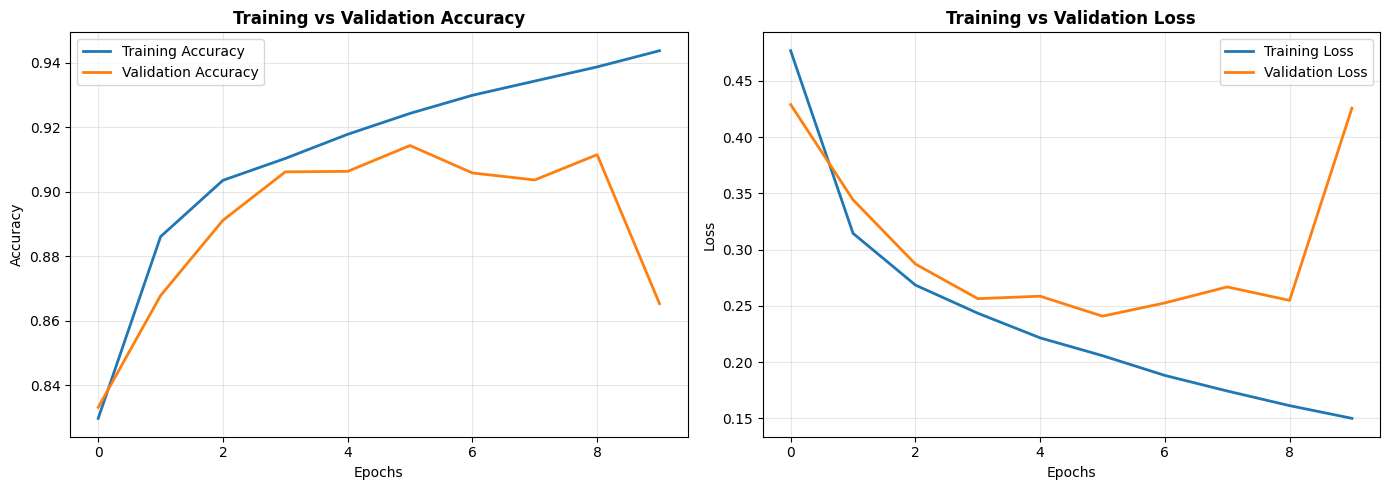

In [23]:
# Plot Training History (Accuracy & Loss) using utility function
# Purpose: Visualize model performance improvements across epochs
# Shows both training and validation metrics to detect overfitting

plot_training_history(history, figsize=(14, 5))

In [24]:
# Both accuracy and loss curves are shown together for comprehensive visualization.
print(" Training history visualization complete (see cell above)")

 Training history visualization complete (see cell above)


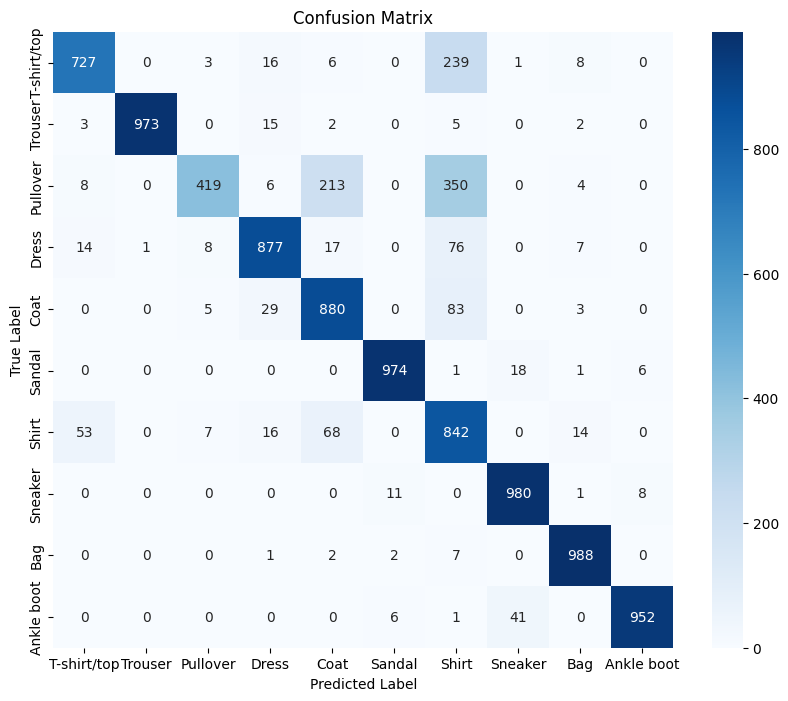


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.90      0.73      0.81      1000
     Trouser       1.00      0.97      0.99      1000
    Pullover       0.95      0.42      0.58      1000
       Dress       0.91      0.88      0.89      1000
        Coat       0.74      0.88      0.80      1000
      Sandal       0.98      0.97      0.98      1000
       Shirt       0.52      0.84      0.65      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.96      0.99      0.97      1000
  Ankle boot       0.99      0.95      0.97      1000

    accuracy                           0.86     10000
   macro avg       0.89      0.86      0.86     10000
weighted avg       0.89      0.86      0.86     10000



In [25]:
# Evaluation Metrics — Accuracy, Precision, Recall, Confusion Matrix
# Purpose:
# – Visualize confusion matrix to understand per-class performance
# – Generate classification report with precision, recall, F1-score

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(class_names.values()),
            yticklabels=list(class_names.values()))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Classification Report (Precision, Recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_labels, target_names=list(class_names.values())))

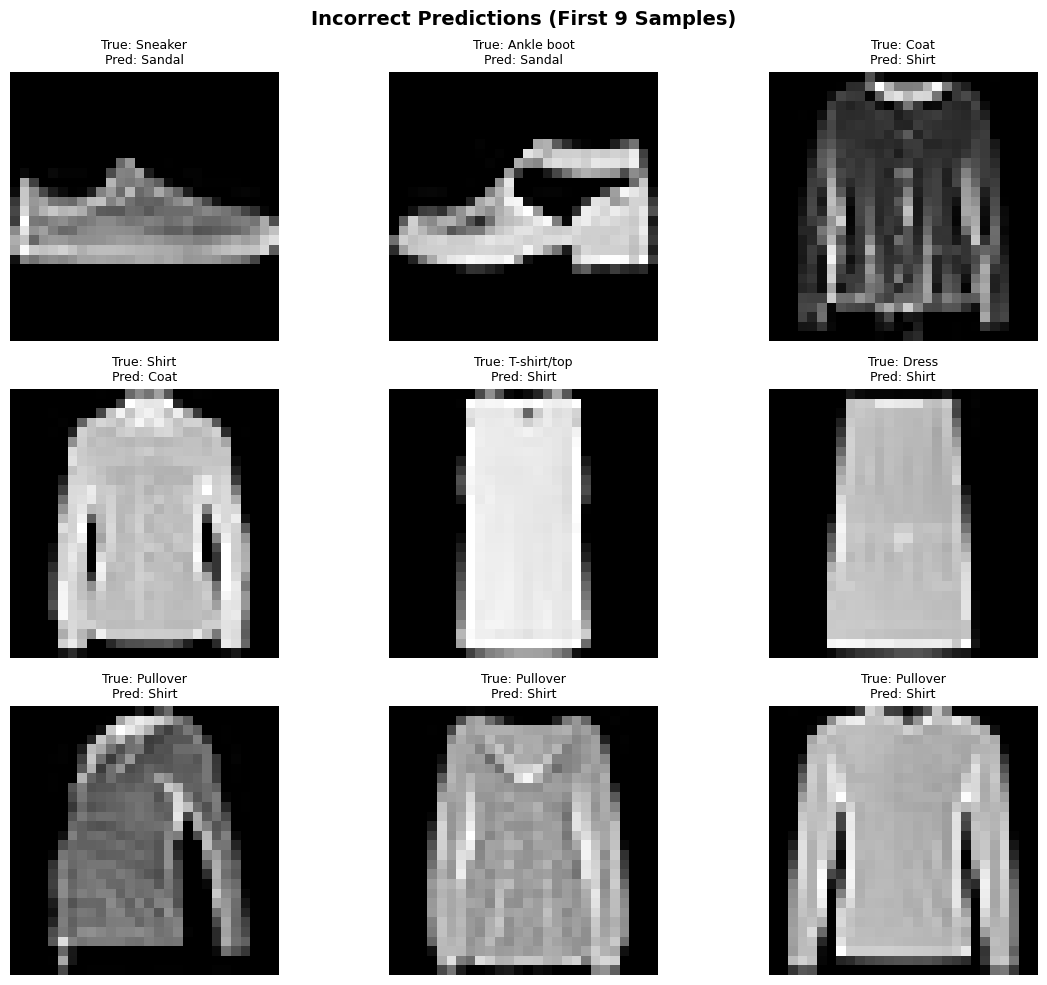

In [26]:
# Visualize Incorrect Predictions using utility function
# Purpose:
# – Understand where the model struggles
# – Identify patterns in misclassifications
# – Useful for debugging and reporting

incorrect_indices = np.where(y_pred_labels != y_test)[0]
X_test_incorrect = X_test[incorrect_indices]
y_test_incorrect = y_test[incorrect_indices]
y_pred_incorrect = y_pred_labels[incorrect_indices]

plot_prediction_comparison(X_test_incorrect, y_test_incorrect, y_pred_incorrect, 
                          class_names, prediction_type='incorrect', num_images=9)

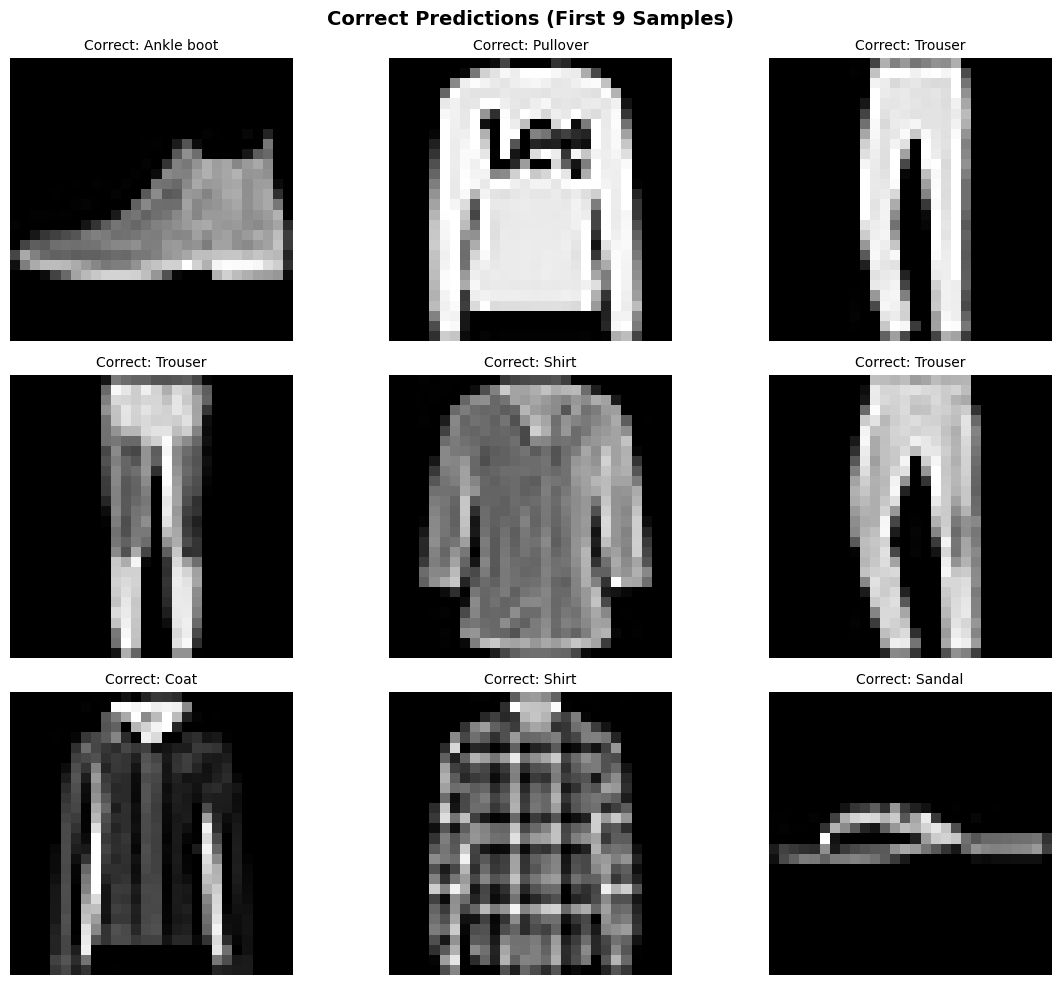

In [27]:
# Visualize Correct Predictions using utility function
# Purpose:
# – See where the model performs well
# – Highlight correctly classified examples for completeness
# – Build confidence in model reliability

correct_indices = np.where(y_pred_labels == y_test)[0]
X_test_correct = X_test[correct_indices]
y_test_correct = y_test[correct_indices]

plot_prediction_comparison(X_test_correct, y_test_correct, y_test_correct, 
                          class_names, prediction_type='correct', num_images=9)